# 02 · Late deliveries and 1-star reviews

**Question.** How much worse are reviews when an order arrives after the promised date, and does the gap
survive controls for basket, freight, payment, region and category?

**Population.** `marts.fact_orders`, delivered orders with a delivered date (96,470). The late share uses all of
them; review metrics use the ones with a review (latest review per order).

**Definitions** (`docs/kpi_definitions.md`): late = `delivered_customer_at::date > estimated_delivery_at::date`;
`days_late` = the same difference in days (negative = early); 1-star = latest review score = 1.

Sections: 1 descriptives · 2 two-proportion z-test · 3 robustness (chi-square, Mann–Whitney, sensitivity) ·
4 logistic regression with controls · 5 caveats · 6 summary for the resume.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "PLAN.md").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportion_confint

from scripts import db
from scripts.plot_style import BLUE, INK_2, ORANGE, apply_style, save_fig
from scripts.stats_helpers import days_late_bucket, top_n_or_other, two_proportion_summary

apply_style()


def fmt_p(p: float) -> str:
    # p-values below float precision print as "< 1e-300" instead of 0.
    return f"= {p:.1e}" if p > 0 else "< 1e-300"


pd.set_option("display.max_columns", 50, "display.width", 140, "display.float_format", "{:,.4f}".format)
SEED = 42

## 0. Load

One row per delivered order with a delivered date. `top_category` = English category of the order's most
expensive item (ties broken by item number), taken from `fact_order_items` → `dim_product`.

In [2]:
SQL = """
with item_category as (
    select
        fi.order_id,
        coalesce(p.category_en, 'unknown') as category,
        row_number() over (partition by fi.order_id order by fi.price desc, fi.order_item_id) as rn
    from marts.fact_order_items as fi
    inner join marts.dim_product as p on p.product_key = fi.product_key
)
select
    o.order_id, o.purchased_at, o.is_late, o.days_late, o.review_score, o.is_one_star,
    o.items_value, o.freight_value, o.items_count, o.sellers_count, o.payment_type_primary,
    o.promised_days, o.delivery_days, o.customer_region, ic.category as top_category
from marts.fact_orders as o
left join item_category as ic on ic.order_id = o.order_id and ic.rn = 1
where o.is_late is not null
"""
df = db.read_sql(SQL)
num_cols = ["items_value", "freight_value", "promised_days", "delivery_days"]
df[num_cols] = df[num_cols].astype(float)
df["is_late"] = df["is_late"].astype(bool)
print(f"{len(df):,} delivered orders with a delivered date; {df['review_score'].notna().sum():,} with a review")

96,470 delivered orders with a delivered date; 95,824 with a review


## 1. Descriptives

### 1a. Late share (resume: 6.8% of orders)

In [3]:
n_dated = len(df)
n_late = int(df["is_late"].sum())
late_share = n_late / n_dated
lo, hi = proportion_confint(n_late, n_dated, method="wilson")
print(f"Late share: {late_share:.2%} ({n_late:,} / {n_dated:,}); 95% Wilson CI {lo:.2%} – {hi:.2%}")

Late share: 6.77% (6,534 / 96,470); 95% Wilson CI 6.62% – 6.93%


### 1b. 2×2 table: late × 1-star (orders with a review)

In [4]:
rv = df[df["review_score"].notna()].copy()
rv["review_score"] = rv["review_score"].astype(int)
rv["is_one_star"] = rv["is_one_star"].astype(bool)

two_by_two = pd.crosstab(rv["is_late"].map({True: "late", False: "on time"}),
                         rv["is_one_star"].map({True: "1-star", False: "2-5 stars"}), margins=True)
two_by_two["1-star rate"] = two_by_two["1-star"] / two_by_two["All"]
two_by_two

is_one_star,1-star,2-5 stars,All,1-star rate
is_late,,,,
late,3431,2950,6381,0.5377
on time,5920,83523,89443,0.0662
All,9351,86473,95824,0.0976


In [5]:
x_late, n_late_rv = int(rv.loc[rv["is_late"], "is_one_star"].sum()), int(rv["is_late"].sum())
x_ok, n_ok_rv = int(rv.loc[~rv["is_late"], "is_one_star"].sum()), int((~rv["is_late"]).sum())
mean_scores = rv.groupby("is_late")["review_score"].mean()
print(f"1-star rate: late {x_late / n_late_rv:.1%} ({x_late:,}/{n_late_rv:,}) vs "
      f"on time {x_ok / n_ok_rv:.1%} ({x_ok:,}/{n_ok_rv:,})")
print(f"Mean review score: late {mean_scores[True]:.2f} vs on time {mean_scores[False]:.2f}")

1-star rate: late 53.8% (3,431/6,381) vs on time 6.6% (5,920/89,443)
Mean review score: late 2.27 vs on time 4.29


### 1c. Dose-response: 1-star rate by days late

If lateness drives bad reviews, the 1-star rate should climb with *how* late the order is, not just jump at
zero. Error bars are 95% Wilson intervals.

In [6]:
rv["days_late_bucket"] = days_late_bucket(rv["days_late"])
dose = (rv.groupby("days_late_bucket", observed=False)
          .agg(orders=("is_one_star", "size"), one_star=("is_one_star", "sum"),
               mean_score=("review_score", "mean")))
dose["one_star_rate"] = dose["one_star"] / dose["orders"]
ci = proportion_confint(dose["one_star"], dose["orders"], method="wilson")
dose["ci_low"], dose["ci_high"] = ci
dose

,orders,one_star,mean_score,one_star_rate,ci_low,ci_high
days_late_bucket,,,,,,
<=-7,75744,4914,4.3130,0.0649,0.0631,0.0667
-6..0,13699,1006,4.1655,0.0734,0.0692,0.0779
1-3,1852,465,3.2910,0.2511,0.2319,0.2713
4-7,1748,1024,2.1030,0.5858,0.5626,0.6087
8-14,1446,1021,1.6708,0.7061,0.6821,0.7290
15+,1335,921,1.7236,0.6899,0.6646,0.7141


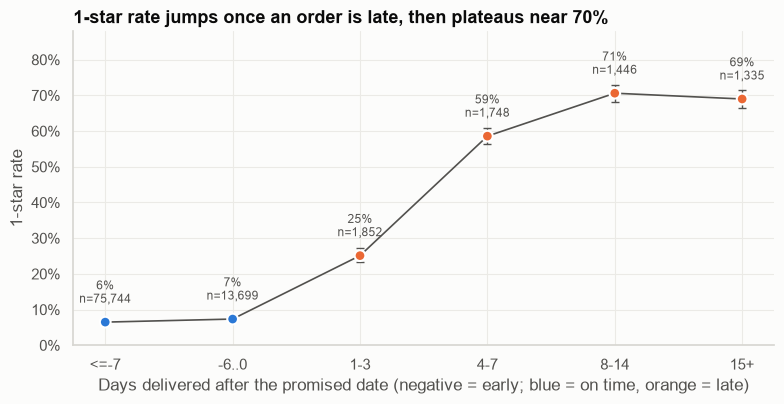

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(dose))
colors = [BLUE if label in ("<=-7", "-6..0") else ORANGE for label in dose.index]
ax.errorbar(x, dose["one_star_rate"], yerr=[dose["one_star_rate"] - dose["ci_low"],
            dose["ci_high"] - dose["one_star_rate"]], fmt="none", ecolor=INK_2, capsize=3, lw=1)
ax.plot(x, dose["one_star_rate"], color=INK_2, lw=1.2, zorder=1)
ax.scatter(x, dose["one_star_rate"], s=60, c=colors, zorder=2, edgecolor="white", linewidth=1.5)
for xi, (rate, n) in enumerate(zip(dose["one_star_rate"], dose["orders"], strict=True)):
    ax.annotate(f"{rate:.0%}\nn={n:,}", (xi, rate), textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=8.5, color=INK_2)
ax.set_xticks(x, dose.index)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylim(0, min(1, dose["ci_high"].max() + 0.15))
ax.set(title="1-star rate jumps once an order is late, then plateaus near 70%",
       xlabel="Days delivered after the promised date (negative = early; blue = on time, orange = late)",
       ylabel="1-star rate")
plt.tight_layout()
save_fig(fig, "one_star_by_days_late")
plt.show()

## 2. Two-proportion z-test

H0: the 1-star rate is the same for late and on-time orders. Two-sided `proportions_ztest`; the difference
gets a Newcombe (Wilson-score) 95% CI; risk and odds ratios get log-scale Wald CIs.

In [8]:
zt = two_proportion_summary(x_late, n_late_rv, x_ok, n_ok_rv)
pd.Series(zt).to_frame("value")

,value
p1,0.5377
p2,0.0662
diff,0.4715
diff_ci_low,0.4591
diff_ci_high,0.4838
z,122.6223
p_value,0.0000
risk_ratio,8.1238
rr_ci_low,7.8560
rr_ci_high,8.4007


In [9]:
print(f"Late {zt['p1']:.1%} vs on time {zt['p2']:.1%}: +{zt['diff']:.1%} "
      f"(95% CI {zt['diff_ci_low']:.1%} – {zt['diff_ci_high']:.1%}), z = {zt['z']:.1f}, p {fmt_p(zt['p_value'])}")
print(f"Risk ratio {zt['risk_ratio']:.2f}x (95% CI {zt['rr_ci_low']:.2f} – {zt['rr_ci_high']:.2f}); "
      f"odds ratio {zt['odds_ratio']:.1f} (95% CI {zt['or_ci_low']:.1f} – {zt['or_ci_high']:.1f})")

Late 53.8% vs on time 6.6%: +47.2% (95% CI 45.9% – 48.4%), z = 122.6, p < 1e-300
Risk ratio 8.12x (95% CI 7.86 – 8.40); odds ratio 16.4 (95% CI 15.5 – 17.4)


**Risk ratio vs odds ratio.** The resume quotes the risk ratio (~8x): "late orders are 8 times as likely
to get a 1-star review". The odds ratio (~16) is twice as large because the outcome is common among late
orders (54%); odds only approximate risk when the outcome is rare. Business readers get risk ratios and
marginal effects; the odds ratio is reported for the logistic model.

## 3. Robustness

### 3a. Chi-square: late × the full 1–5 distribution

The 1-star split throws away information. Does the whole score distribution shift?

In [10]:
dist = pd.crosstab(rv["is_late"].map({True: "late", False: "on time"}), rv["review_score"])
chi2, chi_p, dof, _ = stats.chi2_contingency(dist)
cramers_v = np.sqrt(chi2 / (dist.values.sum() * (min(dist.shape) - 1)))
print(f"chi2 = {chi2:,.0f}, dof = {dof}, p {fmt_p(chi_p)}, Cramér's V = {cramers_v:.3f}")
dist.div(dist.sum(axis=1), axis=0).style.format("{:.1%}")

chi2 = 16,749, dof = 4, p < 1e-300, Cramér's V = 0.418


review_score,1,2,3,4,5
is_late,,,,,
late,53.8%,8.7%,10.9%,10.2%,16.5%
on time,6.6%,2.6%,8.1%,20.4%,62.3%


### 3b. Mann–Whitney U on review scores

Review score is **ordinal** (1–5) and heavily skewed (most reviews are 5), so a t-test's
interval-scale and normal-mean assumptions are a poor fit. Mann–Whitney compares the rank distributions.
Effect size: rank-biserial correlation r = 1 − 2U/(n1·n2), where U is the late group's statistic; r < 0 means
late orders score lower.

In [11]:
late_scores = rv.loc[rv["is_late"], "review_score"]
ok_scores = rv.loc[~rv["is_late"], "review_score"]
mw = stats.mannwhitneyu(late_scores, ok_scores, alternative="two-sided")
rank_biserial = 2 * mw.statistic / (len(late_scores) * len(ok_scores)) - 1
print(f"Median score late {late_scores.median():.0f} vs on time {ok_scores.median():.0f}; "
      f"U = {mw.statistic:,.0f}, p {fmt_p(mw.pvalue)}, rank-biserial r = {rank_biserial:.3f}")

Median score late 1 vs on time 5; U = 103,305,546, p < 1e-300, rank-biserial r = -0.638


### 3c. Sensitivity: does the result depend on the 1-day boundary?

A same-day or next-day slip might be a timezone/data-entry artefact. Re-run the comparison with
late = `days_late > 1` (orders 1 day late move to "on time").

In [12]:
late2 = rv["days_late"] > 1
s2 = two_proportion_summary(int(rv.loc[late2, "is_one_star"].sum()), int(late2.sum()),
                            int(rv.loc[~late2, "is_one_star"].sum()), int((~late2).sum()))
print(f"days_late > 1: share of reviewed orders {late2.mean():.2%}; 1-star {s2['p1']:.1%} vs {s2['p2']:.1%}, "
      f"risk ratio {s2['risk_ratio']:.1f}x")

days_late > 1: share of reviewed orders 5.80%; 1-star 59.8% vs 6.7%, risk ratio 9.0x


## 4. Logistic regression with controls

Late orders may differ from on-time ones in ways that *also* drive bad reviews: bigger baskets, multi-seller
orders, far-away regions, bulky categories, long promises. The model holds these fixed:

`is_one_star ~ is_late + log1p(items_value) + freight_ratio + items_count + C(multi_seller)
+ C(payment_type_primary) + promised_days + C(customer_region) + C(top_category_group)`

- `freight_ratio` = freight / (items + freight); `multi_seller` = more than one seller in the order.
- `top_category_group` = 15 most common top categories, rest → `other` (keeps cells populated).
- `payment_type_primary`: credit card, boleto, voucher; debit card and the 1 order with no payment row → `other`.
  (Left alone, that single no-payment order is perfectly separated and stops the fit converging.)

Inference (odds ratios, AME, pseudo-R²) uses the full sample. Discrimination (AUC) refits the same formula on
a stratified 80% split and scores the 20% holdout.

In [13]:
m = rv.copy()
m["is_late"] = m["is_late"].astype(int)
m["is_one_star"] = m["is_one_star"].astype(int)
m["freight_ratio"] = m["freight_value"] / (m["items_value"] + m["freight_value"])
m["multi_seller"] = (m["sellers_count"] > 1).map({True: "yes", False: "no"})
m["payment_type_primary"] = top_n_or_other(m["payment_type_primary"], 3)
m["top_category_group"] = top_n_or_other(m["top_category"], 15)

FORMULA = ("is_one_star ~ is_late + np.log1p(items_value) + freight_ratio + items_count + C(multi_seller)"
           " + C(payment_type_primary, Treatment('credit_card')) + promised_days"
           " + C(customer_region, Treatment('Southeast')) + C(top_category_group, Treatment('other'))")
logit = smf.logit(FORMULA, data=m).fit(disp=False, maxiter=200)
print(f"n = {int(logit.nobs):,}; converged = {logit.mle_retvals['converged']}; "
      f"McFadden pseudo-R² = {logit.prsquared:.3f}; LLR p {fmt_p(logit.llr_pvalue)}")

n = 95,824; converged = True; McFadden pseudo-R² = 0.179; LLR p < 1e-300


In [14]:
ci = logit.conf_int()
or_table = pd.DataFrame({"odds_ratio": np.exp(logit.params), "ci_low": np.exp(ci[0]),
                         "ci_high": np.exp(ci[1]), "p_value": logit.pvalues}).drop(index="Intercept")
or_table.sort_values("odds_ratio", ascending=False)

,odds_ratio,ci_low,ci_high,p_value
is_late,19.1454,18.0587,20.2975,0.0000
C(multi_seller)[T.yes],4.0729,3.5798,4.6339,0.0000
freight_ratio,2.2853,1.6233,3.2173,0.0000
items_count,1.5332,1.4758,1.5928,0.0000
"C(top_category_group, Treatment('other'))[T.computers_accessories]",1.2382,1.1199,1.3690,0.0000
"C(top_category_group, Treatment('other'))[T.telephony]",1.2214,1.0764,1.3859,0.0019
"C(top_category_group, Treatment('other'))[T.bed_bath_table]",1.1966,1.0950,1.3077,0.0001
np.log1p(items_value),1.1789,1.1252,1.2352,0.0000
"C(top_category_group, Treatment('other'))[T.watches_gifts]",1.1188,1.0006,1.2510,0.0488
"C(top_category_group, Treatment('other'))[T.electronics]",1.1153,0.9516,1.3071,0.1778


### Average marginal effect of `is_late`

`get_margeff(at="overall", dummy=True)`: for each order, predicted 1-star probability with `is_late = 1`
minus with `is_late = 0`, averaged over the sample. This is the "percentage-point" effect a stakeholder can
read, and it is the controlled counterpart of the raw 47-pp gap.

In [15]:
me = logit.get_margeff(at="overall", method="dydx", dummy=True)
me_frame = me.summary_frame()
ame = me_frame.loc["is_late"]
print(f"AME of is_late: +{ame['dy/dx']:.1%} (95% CI {ame['Conf. Int. Low']:.1%} – {ame['Cont. Int. Hi.']:.1%}), "
      f"p {fmt_p(ame['Pr(>|z|)'])}")
print(f"Adjusted odds ratio of is_late: {or_table.loc['is_late', 'odds_ratio']:.1f} "
      f"(95% CI {or_table.loc['is_late', 'ci_low']:.1f} – {or_table.loc['is_late', 'ci_high']:.1f})")
print(f"Raw difference for comparison: +{zt['diff']:.1%}")

AME of is_late: +48.1% (95% CI 46.9% – 49.3%), p < 1e-300
Adjusted odds ratio of is_late: 19.1 (95% CI 18.1 – 20.3)
Raw difference for comparison: +47.2%


### Holdout AUC (20%)

In [16]:
train, test = train_test_split(m, test_size=0.2, random_state=SEED, stratify=m["is_one_star"])
logit_train = smf.logit(FORMULA, data=train).fit(disp=False, maxiter=200)
auc_full = roc_auc_score(test["is_one_star"], logit_train.predict(test))
auc_late_only = roc_auc_score(test["is_one_star"], smf.logit("is_one_star ~ is_late", data=train)
                              .fit(disp=False).predict(test))
print(f"Holdout AUC: full model {auc_full:.3f}; is_late alone {auc_late_only:.3f}")

Holdout AUC: full model 0.753; is_late alone 0.672


### Multicollinearity (VIF)

Computed on the model's design matrix (dummies included, intercept excluded from the report). VIF < 5 means
the coefficient of interest isn't inflated by overlap with the controls.

In [17]:
X = pd.DataFrame(logit.model.exog, columns=logit.model.exog_names)
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns, name="VIF")
vif = vif.drop(index="Intercept").sort_values(ascending=False)
print(f"Max VIF {vif.max():.2f} ({vif.idxmax()}); VIF of is_late {vif['is_late']:.2f}")
vif.head(10).to_frame()

Max VIF 3.55 (freight_ratio); VIF of is_late 1.01


,VIF
freight_ratio,3.5504
np.log1p(items_value),3.4843
"C(top_category_group, Treatment('other'))[T.bed_bath_table]",1.3223
promised_days,1.3192
"C(top_category_group, Treatment('other'))[T.health_beauty]",1.3042
items_count,1.2984
"C(top_category_group, Treatment('other'))[T.sports_leisure]",1.2650
"C(customer_region, Treatment('Southeast'))[T.Northeast]",1.2500
"C(top_category_group, Treatment('other'))[T.computers_accessories]",1.2363
"C(top_category_group, Treatment('other'))[T.furniture_decor]",1.2286


## 5. Caveats

- **Observational, not causal.** Orders weren't randomly made late. The controls, the dose-response curve and
  the stable adjusted effect make "lateness hurts reviews" the most plausible reading, but residual
  confounding remains: product quality, seller behaviour (a sloppy seller may ship late *and* ship the wrong
  item) and carrier damage are not in the data.
- **Survivorship.** Only delivered orders with a delivered date are in scope; canceled/never-delivered
  orders, which are likely angrier still, are excluded.
- **Missing reviews.** 646 delivered orders have no review; if silent customers differ, the rates shift slightly.
- **Lateness can't be randomized** (we can't make orders late on purpose), so the experiment in
  `03_ab_test_design.ipynb` tests a *mitigation* for orders predicted to be late, not lateness itself.
- The model is explanatory; its modest AUC is expected because most 1-star reviews have causes other than
  lateness (and most orders are on time).

## 6. Summary (numbers for the resume and PROGRESS.md)

In [18]:
summary = pd.Series({
    "late share (delivered, dated)": f"{late_share:.2%} ({n_late:,} / {n_dated:,})",
    "1-star rate late vs on time": f"{zt['p1']:.1%} vs {zt['p2']:.1%}",
    "risk ratio (95% CI)": f"{zt['risk_ratio']:.2f}x ({zt['rr_ci_low']:.2f} – {zt['rr_ci_high']:.2f})",
    "odds ratio, raw": f"{zt['odds_ratio']:.1f}",
    "z-test": f"z = {zt['z']:.1f}, p {fmt_p(zt['p_value'])}",
    "difference (95% CI)": f"+{zt['diff']:.1%} ({zt['diff_ci_low']:.1%} – {zt['diff_ci_high']:.1%})",
    "mean score late vs on time": f"{mean_scores[True]:.2f} vs {mean_scores[False]:.2f}",
    "chi-square (late x score)": f"chi2 = {chi2:,.0f}, p {fmt_p(chi_p)}, V = {cramers_v:.3f}",
    "Mann-Whitney": f"p {fmt_p(mw.pvalue)}, rank-biserial r = {rank_biserial:.3f}",
    "logit adjusted OR of is_late": f"{or_table.loc['is_late', 'odds_ratio']:.1f}",
    "logit AME of is_late": f"+{ame['dy/dx']:.1%} ({ame['Conf. Int. Low']:.1%} – {ame['Cont. Int. Hi.']:.1%})",
    "pseudo-R2 / holdout AUC": f"{logit.prsquared:.3f} / {auc_full:.3f}",
    "max VIF": f"{vif.max():.2f}",
}, name="value")
summary.to_frame()

,value
"late share (delivered, dated)","6.77% (6,534 / 96,470)"
1-star rate late vs on time,53.8% vs 6.6%
risk ratio (95% CI),8.12x (7.86 – 8.40)
"odds ratio, raw",16.4
z-test,"z = 122.6, p < 1e-300"
difference (95% CI),+47.2% (45.9% – 48.4%)
mean score late vs on time,2.27 vs 4.29
chi-square (late x score),"chi2 = 16,749, p < 1e-300, V = 0.418"
Mann-Whitney,"p < 1e-300, rank-biserial r = -0.638"
logit adjusted OR of is_late,19.1
